# MLB Salary Cap Analysis - Case Study 3

## Research Question
With MLB owners proposing a \\$245.3M cap and \\$171.2M floor for the 2027 season, 
which teams face the greatest structural pressure on either end — and what does 
20 years of World Series history suggest about what's actually at stake competitively?

## Structure
1. Cap Pressure - teams currently above \$245.3M
2. Floor Pressure - teams currently under \$171.2M
3. World Series History - payroll of champions over last 20 years
4. Closing Thesis - asymmetric pressure analysis

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd        # tabular data — loading, filtering, merging, transforming
import numpy as np         # numerical operations and array math
import matplotlib.pyplot as plt  # base visualization library
import seaborn as sns      # statistical visualizations, cleaner defaults than raw matplotlib
import pybaseball as pb    # pulls data from Baseball Reference, FanGraphs, Statcast
import requests

## Section 1 — Cap Pressure

Identifying which MLB teams currently exceed the proposed \$245.3M salary cap, 
and quantifying how much they would need to shed to comply.

### Data Source — 2026 Team Payrolls

Current team payroll data is sourced from Spotrac, which tracks real-time 
MLB salary commitments. Since no direct download is available, we scrape 
the data programmatically using pandas' `read_html()` function. We're using 
2026 figures as the most relevant proxy for evaluating pressure against the 
proposed 2027 salary cap and floor thresholds.

In [2]:
# url = 'https://www.spotrac.com/mlb/payroll/_/year/2026'
# tables = pd.read_html(url)
# print(len(tables))

# headers = {'User-Agent': 'Mozilla/5.0'}
# response = requests.get(url, headers=headers)
# tables = pd.read_html(response.text)
# print(len(tables))

### A Note on Data Collection

Initial efforts to scrape 2026 team payroll figures directly from Spotrac 
were unsuccessful due to the site's use of JavaScript to render its data 
tables. Attempts using `requests` and `pd.read_html()` retrieved only 
static HTML — the payroll table itself is loaded dynamically and requires 
a browser to execute. A full scraping solution would utilize Python's 
`Selenium` package to control a headless browser and capture the rendered 
output. For simplicity, 2026 payroll figures were manually collected from 
Spotrac and loaded via CSV.

In [3]:
payroll_df = pd.read_csv('spotrac-team-payroll-2026.csv')
payroll_df.head()

,Team,Total Payroll
0,PHI,"280,839,235"
1,TOR,"282,552,776"
2,NYY,"292,892,832"
3,NYM,"334,085,472"
4,ATL,"267,889,815"


In [4]:
payroll_df.dtypes

Team             str
Total Payroll    str
dtype: object

In [5]:
payroll_df['Total Payroll'] = payroll_df['Total Payroll'].str.replace(',','').astype(int)

In [6]:
payroll_df.head()

,Team,Total Payroll
0,PHI,280839235
1,TOR,282552776
2,NYY,292892832
3,NYM,334085472
4,ATL,267889815


In [7]:
CAP = 245_300_000 # underscores are just visual
over_cap = payroll_df[payroll_df['Total Payroll'] > CAP].copy()
print(over_cap)

  Team  Total Payroll
0  PHI      280839235
1  TOR      282552776
2  NYY      292892832
3  NYM      334085472
4  ATL      267889815
5  LAD      302198379


In [8]:
over_cap['Over Cap'] = over_cap['Total Payroll'] - CAP
over_cap.sort_values('Over Cap', ascending=False)

,Team,Total Payroll,Over Cap
3,NYM,334085472,88785472
5,LAD,302198379,56898379
2,NYY,292892832,47592832
1,TOR,282552776,37252776
0,PHI,280839235,35539235
4,ATL,267889815,22589815


This is looking at the teams who would fall over the cap limit. Taking the difference ("Over Cap"), leaves us with three teams over /$45 million that they would need to shed. That's likely a taller task than the bottom three (TOR, PHI, ATL) which would likely need to remove bloated middle-relief contracts from their payroll.  

In [9]:
FLOOR = 171_200_000
under_floor = payroll_df[payroll_df['Total Payroll'] < FLOOR].copy()
under_floor.count()

Team             15
Total Payroll    15
dtype: int64

In [10]:
under_floor['Under Floor'] = FLOOR - under_floor['Total Payroll']
under_floor.sort_values('Under Floor', ascending=False)

,Team,Total Payroll,Under Floor
26,MIA,80374373,90825627
23,CLE,80471618,90728382
27,CHW,90997868,80202132
29,WSH,92605844,78594156
28,STL,93898025,77301975
24,ATH,94163715,77036285
21,TB,103281480,67918520
17,PIT,103967933,67232067
25,MIN,105992179,65207821
22,COL,118106572,53093428


A note on the data: we're using 2026 salary totals to evaluate teams against the proposed 2027 cap and floor. These aren't 2027 commitments — payrolls shift year to year as contracts expire and teams restructure — so this is a best-available proxy rather than a precise forecast. It's directionally sound for identifying which teams face structural pressure, but actual 2027 figures will move. 

In [11]:
print(over_cap['Over Cap'].sum())
print(under_floor['Under Floor'].sum())

288658509
862583363


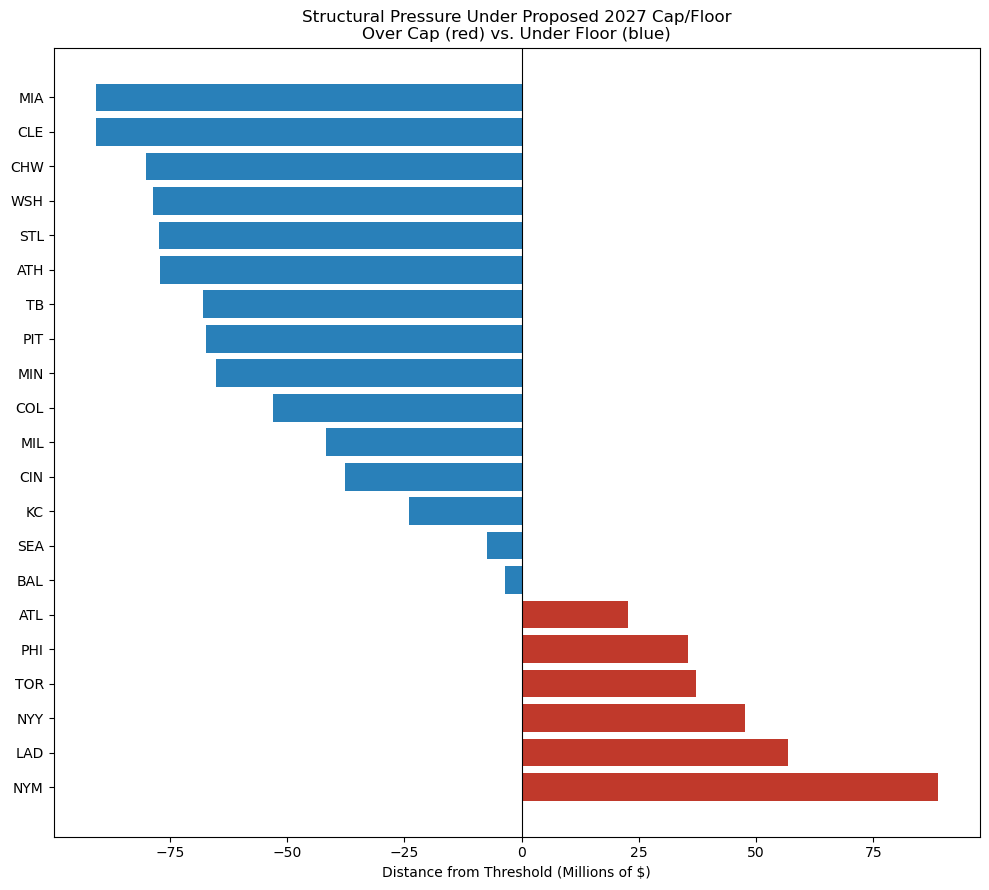

In [12]:
# Cap teams = positive distance from the line
cap_plot = over_cap[['Team', 'Over Cap']].copy()
cap_plot = cap_plot.rename(columns={'Over Cap': 'Distance'})
cap_plot['Side'] = 'Over Cap'

floor_plot = under_floor[['Team', 'Under Floor']].copy()
floor_plot = floor_plot.rename(columns={'Under Floor': 'Distance'})
floor_plot['Distance'] = -floor_plot['Distance']
floor_plot['Side'] = 'Under Floor'

#combine both sides into one dataframe
combined = pd.concat([cap_plot, floor_plot])
combined = combined.sort_values('Distance', ascending=False)

#Plot
fig, ax = plt.subplots(figsize=(10, 9))
colors = combined['Side'].map({'Over Cap': '#c0392b', 'Under Floor': '#2980b9'})
ax.barh(combined['Team'], combined['Distance']/1_000_000, color=colors)

ax.axvline(0, color='black', linewidth=0.8) #threshould line at 0
ax.set_xlabel('Distance from Threshold (Millions of $)')
ax.set_title('Structural Pressure Under Proposed 2027 Cap/Floor\nOver Cap (red) vs. Under Floor (blue)')
plt.tight_layout()
plt.show()

In [13]:
# Import the World Series contenders from 2025-2025
# Pulled data from https://www.thebaseballcube.com/content/payroll/#google_vignette
world_series_df = pd.read_csv('2005-2025-ws-payroll.csv')
world_series_df.head()

,year,champion,contender,champion-payroll,contender-payroll,league-total-payroll
0,2005,CHW,HOU,"75,228,000","76,779,022","2,191,886,898"
1,2006,STL,DET,"88,891,371","82,612,866","2,326,706,685"
2,2007,BOS,COL,"143,026,214","54,424,000","2,476,688,987"
3,2008,PHI,TB,"98,269,880","43,820,597","2,686,433,458"
4,2009,NYY,PHI,"201,449,289","113,004,048","2,655,395,194"


In [14]:
world_series_df['champion-payroll'] = world_series_df['champion-payroll'].str.replace(',','').astype(int)
world_series_df['contender-payroll'] = world_series_df['contender-payroll'].str.replace(',','').astype(int)
world_series_df['league-total-payroll'] = world_series_df['league-total-payroll'].str.replace(',','').astype(int)

world_series_df.dtypes

year                    int64
champion                  str
contender                 str
champion-payroll        int64
contender-payroll       int64
league-total-payroll    int64
dtype: object

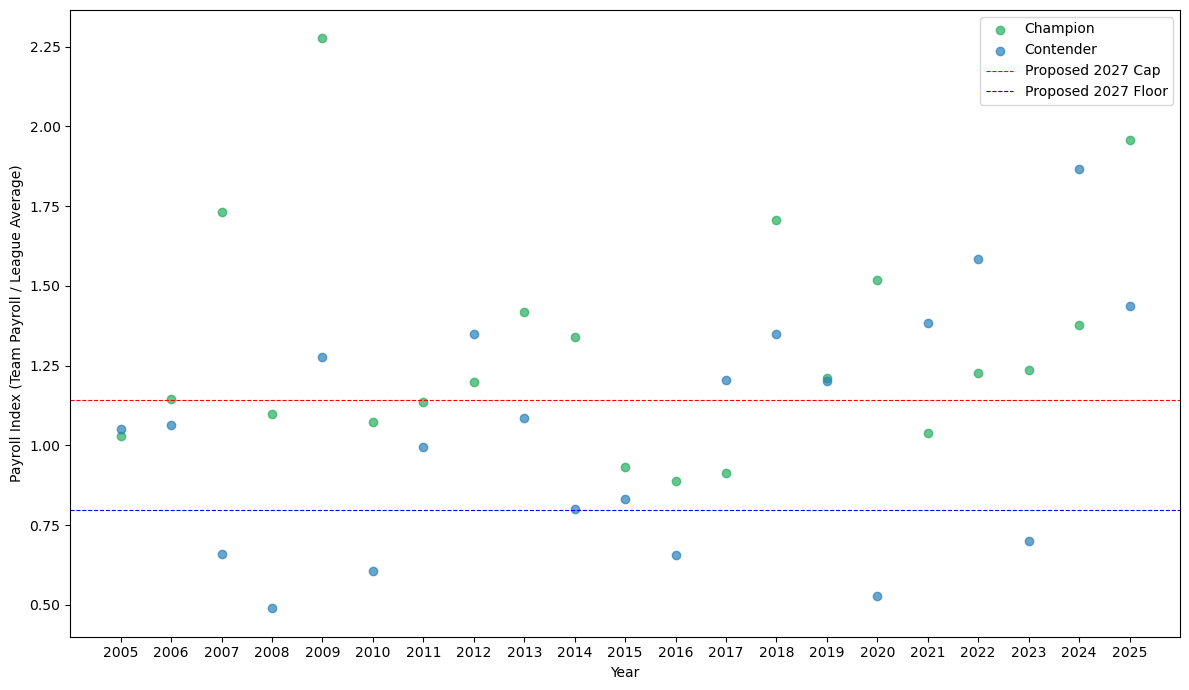

In [17]:
champions = world_series_df[['year','champion','champion-payroll','league-total-payroll']].copy()
champions = champions.rename(columns={'champion':'team','champion-payroll':'payroll'})
champions['Result'] = 'Champion'

contenders = world_series_df[['year','contender','contender-payroll','league-total-payroll']].copy()
contenders = contenders.rename(columns={'contender':'team','contender-payroll':'payroll'})
contenders['Result'] = 'Contender'

world_series_plot = pd.concat([champions,contenders])
world_series_plot['league_avg'] = world_series_plot['league-total-payroll'] / 30
world_series_plot['payroll_index'] = world_series_plot['payroll'] / world_series_plot['league_avg']

# 2026 opening day league total payroll (thebaseballcube.com, retrieved July 2026).
# Kept as a constant rather than a row in the WS csv: that file's grain is one
# World Series per row, and 2026 has no World Series yet.
# Note: stevetheump.com's 2026 total sums ~5.5% lower despite the same stated
# opening-day definition; the Cube figure is used for consistency with the
# 2005-2025 league-total series, which is Cube-sourced.
league_total_2026 = 6_130_926_880
league_avg_2026 = league_total_2026 / 30

# Long-run growth rate (2005 -> 2026 CAGR). We deliberately do NOT project
# forward using the single-year 2025->2026 jump (~20%), which is an outlier.
league_avg_2005 = world_series_plot.loc[world_series_plot['year'] == 2005, 'league_avg'].iloc[0]
cagr = (league_avg_2026 / league_avg_2005) ** (1/21)

# 2027 projection: one year forward from the 2026 actual at the long-run rate.
league_avg_2027_proj = league_avg_2026 * cagr

proposed_cap_2027 = 245_300_000 / league_avg_2027_proj
proposed_floor_2027 = 171_200_000 / league_avg_2027_proj


fig, ax = plt.subplots(figsize=(12, 7))
champ = world_series_plot[world_series_plot['Result'] == 'Champion']
cont  = world_series_plot[world_series_plot['Result'] == 'Contender']

ax.scatter(champ['year'], champ['payroll_index'], color='#27ae60', alpha=0.7, label='Champion')
ax.scatter(cont['year'],  cont['payroll_index'],  color='#2980b9', alpha=0.7, label='Contender')


ax.axhline(proposed_cap_2027, color='red', linewidth=0.8, linestyle='--', label='Proposed 2027 Cap')
ax.axhline(proposed_floor_2027, color='blue', linewidth=0.8, linestyle='--', label='Proposed 2027 Floor')
ax.set_xticks(world_series_plot['year'].unique())
ax.legend()
ax.set_xlabel('Year')
ax.set_ylabel('Payroll Index (Team Payroll / League Average)')
plt.tight_layout()
plt.show()


In [18]:
print(f"2026 league avg: ${league_avg_2026/1e6:.1f}M")
print(f"CAGR 2005-2026: {(cagr-1)*100:.2f}%")
print(f"2027 projected avg: ${league_avg_2027_proj/1e6:.1f}M")
print(f"Cap index: {245_300_000/league_avg_2027_proj:.2f}  Floor index: {171_200_000/league_avg_2027_proj:.2f}")

2026 league avg: $204.4M
CAGR 2005-2026: 5.02%
2027 projected avg: $214.6M
Cap index: 1.14  Floor index: 0.80


This chart plots opening-day payroll for both World Series participants — the champion (green) and the contender they defeated (blue) — for every season from 2005 to 2025, against the proposed 2027 cap ($245.3M) and floor ($171.2M).

Two patterns stand out. First, almost no team — champion or contender — would have exceeded the proposed cap; only the most recent seasons approach it. Second, a large share of teams fall *below* the proposed floor, including multiple World Series champions (e.g., the 2005 White Sox at ~$75M). A spending floor meant to enforce competitiveness would have flagged several of the sport's most successful teams as underspenders.

This mirrors the asymmetry from Section 1: the cap constrains few teams, while the floor pressures many. One important caveat: because MLB payrolls have grown steadily since 2005, earlier teams sit low partly due to nominal-dollar drift rather than genuinely low relative spending. The next section isolates the real effect by ranking each team's payroll *within its own season*, removing inflation from the comparison.

Updated markdown:
Because we're working with payrolls across multiple seasons, we need to normalize the season over season payrolls to adjust to increases. So the idea, would be to take the index of each payroll, relative to the mean of a given season. Using the same source, we pulled the total opening day payroll for the season, divided by the 30 teams, provides us an average payroll for the season. To compare how a given teams payroll compares to said average, we have each teams given payroll and divide it by the season's average payroll. Providing us with a range of values 0.0 through 2.0 and above, where 1.0 represents the average payroll value for tha given season.

For consistency of the 2027 proposed cap and cieling, we needed to perform the same calculation. But because we don't have opening day paryolls for 2027 yet, and don't have 2026 payrolls yet within the dataframe, we plugged in a dummy modifier value of 1.05 as the increase modifier, multiplying by the 2025 season's average payroll. 

Uodated markdown 2.0:
The above diagram represents a normalized view of the salary values across the World Series participants - in addition to the 2027 proposed Cap and Floor. Rather than plotting the z-scores, we've elected to take each team's opening day salary for a given season, and divide it by that season's average payroll (Team Salary['year']/Average League Salary['year']). This level of normalization doesn't sacrifice readibility or quick interpretation. With the average league salary representing 1.0, a team with 1.4 for a given season represents their salary as 40% over the league average for that season. 

The projected opening day salary for 2027 was calculated using an assumed 5% growth rate to the 2025 league-avaerage payroll as a provisional estimate. Until we have a more accruate forcasting of the 2027 salaries once we add in the 2026 opening day salaries. 
